# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

**Linear models assume the output is continuous and unbounded, but real-world outcomes often aren't (for example: probabilities must be 0-1). These tools apply a transformation so the model outputs something meaningful. They keep the interpretable linear structure while handling a wider range of problems.**


2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

**They penalize confident wrong predictions heavily and reward confident correct ones. Minimizing cross-entropy is the same as maximizing the likelihood of your data, so it's a statistically principled way to fit a probability model.**

3. True or false, and explain: Logistic regression is a linear model.

**Partially true. The decision boundary is linear, so it's a generalized linear model. But the relationship between features and the output probability is nonlinear due to the sigmoid function, so it's not purely linear.**


4. True or false, and explain: Logistic regression cannot be used for classification.

**False. It's one of the most classic classifiers. It outputs a probability, and you apply a threshold (for example: greater than 0.5 = class 1) to classify.**


5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

**No. In logistic regression, coefficients represent the change in log-odds, not the predicted probability. The effect on probability is nonlinear and depends on the values of all other features.**


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

**False. Despite having a nonlinear output, logistic regression still has a linear decision boundary. It can't capture nonlinear feature relationships on its own, so feature engineering (for example: interaction terms, polynomial features) is still needed.**


7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**False. They solve different problems. OLS is for continuous outcomes, logistic regression is for categorical ones. Neither is better overall; it depends on your data and problem.**

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 19.18 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [4]:
#Q2.1

import pandas as pd

df = pd.read_csv('./undergrad_ml_assignments/data/data.csv', sep=';')

df = df[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment',
         'Curricular units 1st sem (approved)',
         'Target']]

print("Missing values before cleaning:\n", df.isna().sum())

df = df.dropna()

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(df.head())


Missing values before cleaning:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  dropout  
0                                    0   Dropout        1  
1                                    6  Graduate        0  
2                                    0   Dropout        1  
3    

In [6]:
#Q2.2

from sklearn.linear_model import LogisticRegression

X = df[['Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'Age at enrollment']]

y = df['dropout']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("Logistic Regression Coefficients:")
for var, coef in zip(X.columns, model.coef_[0]):
    print(f"{var}: {coef}")

Logistic Regression Coefficients:
Debtor: 0.5306254196925666
Tuition fees up to date: -2.55654243281313
Scholarship holder: -1.227441522252298
Age at enrollment: 0.04992541246433546


**Q2.2 Answer;**

**The results show that being a debtor increases the probability of dropout (positive coefficient). Being up to date on tuition fees and being a scholarship holder decrease the probability of dropout (negative coefficients), with tuition status having the strongest effect. Age at enrollment slightly increases dropout probability. Overall, being up to date on tuition fees clearly reduces dropout risk.**

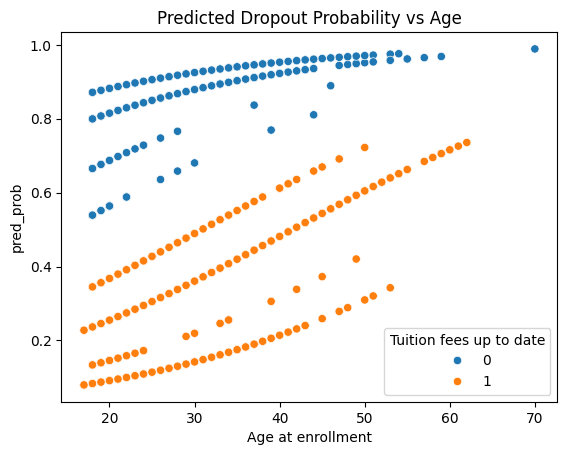

Average predicted probabilities:
Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64
Difference (not up to date - up to date): 0.6125849339840048


In [7]:
#Q2.3

import matplotlib.pyplot as plt
import seaborn as sns

df['pred_prob'] = model.predict_proba(X)[:, 1]

sns.scatterplot(data=df,
                x='Age at enrollment',
                y='pred_prob',
                hue='Tuition fees up to date')

plt.title("Predicted Dropout Probability vs Age")
plt.show()

group_means = df.groupby('Tuition fees up to date')['pred_prob'].mean()

print("Average predicted probabilities:")
print(group_means)

difference = group_means[0] - group_means[1]
print("Difference (not up to date - up to date):", difference)

**Q2.3 Answer:**

**The plot shows that students who are up to date on tuition fees have much lower dropout probabilities than those who are not, across all ages. The effect is consistent rather than limited to a specific age group. On average, being up to date on tuition reduces dropout probability by about 0.61, which is a large decrease.**

In [8]:
#Q2.4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


**Q2.4 Answer:**

**The model’s accuracy is 0.762, meaning it correctly classifies about 76.2% of students.**

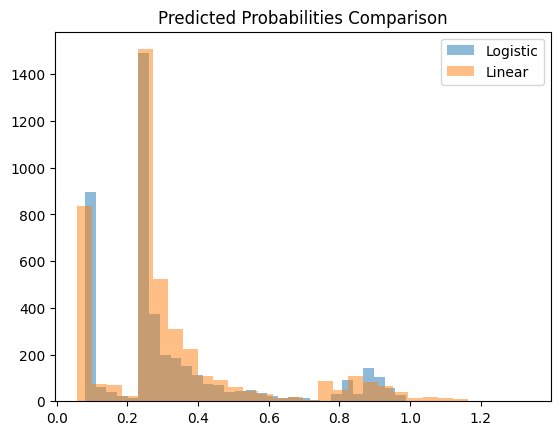

In [9]:
#Q2.5

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)

df['lin_prob'] = lin_model.predict(X)

plt.hist(df['pred_prob'], bins=30, alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], bins=30, alpha=0.5, label='Linear')

plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

**Q2.5 Answer:**

**The logistic regression model produces probabilities between 0 and 1, while the linear model produces some values above 1, which are not valid probabilities. From the histogram, logistic regression gives more realistic and reliable predictions, while the linear model is less appropriate. Overall, logistic regression performs better for predicting dropout probability.**

**Q2.6 Answer:**

**The students most at risk are those who are not up to date on tuition, have debt, and don’t have scholarships, since these factors increase dropout probability. To help them stay enrolled, schools could offer financial help (like payment plans or scholarships) and extra academic support, such as advising or tutoring.**

In [10]:
#Q2.7

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_multi = df[['Debtor',
              'Tuition fees up to date',
              'Curricular units 1st sem (approved)']]

y_multi = df['Target']

multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)

cm_multi = confusion_matrix(y_multi, y_pred_multi)
print("Confusion Matrix:")
print(cm_multi)

probs = multi_model.predict_proba(X_multi)

print("\nSample predicted probabilities:")
print(probs[:5])

Confusion Matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

Sample predicted probabilities:
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q2.7 Answer:**

**The confusion matrix shows that the model does not predict all classes equally well and struggles with some classes more than others. The hard classification using .predict() does not predict every class equally, as some classes are misclassified more often. However, the predicted probabilities from .predict_proba() do assign probabilities to all three classes, even if the final prediction does not always select each class.**

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [11]:
#Q3.1

import pandas as pd

df = pd.read_csv('./undergrad_ml_assignments/data/cirrhosis.csv')

df = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]

print("Missing values before cleaning:\n", df.isna().sum())

df = df.dropna()

print(df.head())

Missing values before cleaning:
 Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64
   Bilirubin Edema             Drug  Stage Status
0       14.5     Y  D-penicillamine    4.0      D
1        1.1     N  D-penicillamine    3.0      C
2        1.4     S  D-penicillamine    4.0      D
3        1.8     S  D-penicillamine    4.0      D
4        3.4     N          Placebo    3.0     CL


**Q3.1 Answer:**

**The data contained missing values in the Drug (106 missing) and Stage (6 missing) columns, while the other variables had no missing values. These missing values were handled by removing rows with missing data using dropna(), ensuring that the analysis is performed only on complete observations.**

In [12]:
#Q3.2

from sklearn.linear_model import LogisticRegression

df['survived'] = df['Status'].isin(['C', 'CL']).astype(int)

df_encoded = pd.get_dummies(df[['Edema', 'Drug']], drop_first=True)

X = pd.concat([df[['Bilirubin']], df_encoded], axis=1)
y = df['survived']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("Logistic Regression Coefficients:")
for var, coef in zip(X.columns, model.coef_[0]):
    print(f"{var}: {coef}")

Logistic Regression Coefficients:
Bilirubin: -0.35142389843544086
Edema_S: -0.45067663255235757
Edema_Y: -1.6110491833168035
Drug_Placebo: 0.23122512449170882


**Q3.2 Answer**

**The results show that higher bilirubin levels decrease survival probability, as indicated by a negative coefficient. Patients with more severe edema (S and especially Y) also have lower survival probability compared to those with no edema. The drug variable (placebo vs. D-penicillamine) has a small positive coefficient, suggesting a slight increase in survival for the placebo group, though the effect is relatively weak compared to bilirubin and edema.**

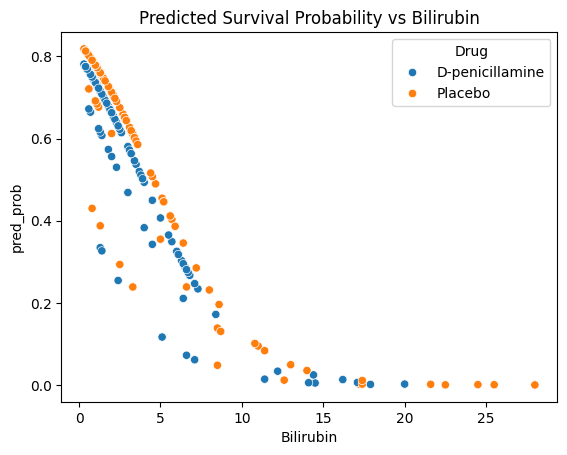

Average predicted survival probabilities:
Drug
D-penicillamine    0.590054
Placebo            0.608902
Name: pred_prob, dtype: float64
Difference (drug - placebo): -0.01884850103850899


In [13]:
#Q3.3

import matplotlib.pyplot as plt
import seaborn as sns

df['pred_prob'] = model.predict_proba(X)[:, 1]

sns.scatterplot(data=df,
                x='Bilirubin',
                y='pred_prob',
                hue='Drug')

plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

group_means = df.groupby('Drug')['pred_prob'].mean()

print("Average predicted survival probabilities:")
print(group_means)

difference = group_means['D-penicillamine'] - group_means['Placebo']
print("Difference (drug - placebo):", difference)

**Q3.3 Answer:**

**The plot shows that survival probability decreases as bilirubin increases for both groups. The drug does not appear to consistently increase survival at any specific bilirubin level, as the points for both groups overlap closely. On average, patients taking the drug have a slightly lower survival probability than those on placebo (difference ≈ -0.018), indicating that the drug does not meaningfully improve survival.**

In [14]:
#Q3.4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


**Q3.4 Answer:**

**The model’s accuracy is 0.737, meaning it correctly classifies about 73.7% of patients.**

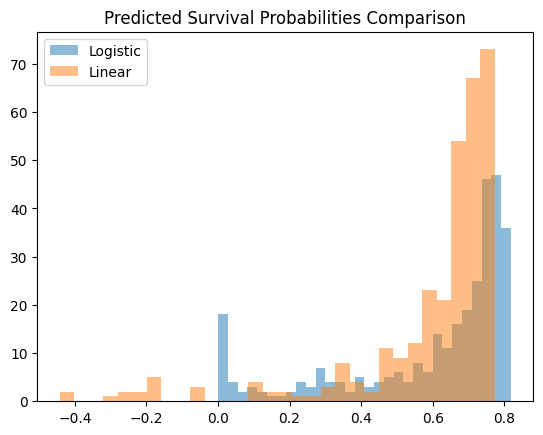

In [15]:
#Q3.5

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)

df['lin_prob'] = lin_model.predict(X)

plt.hist(df['pred_prob'], bins=30, alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], bins=30, alpha=0.5, label='Linear')

plt.legend()
plt.title("Predicted Survival Probabilities Comparison")
plt.show()

**Q3.5 Answer:**

**The logistic regression model produces probabilities between 0 and 1, while the linear model produces some values below 0, which are not valid probabilities. From the histogram, logistic regression provides more realistic and reliable predictions, while the linear model is less appropriate. Overall, logistic regression performs better for predicting survival probability.**

In [16]:
#Q3.6

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df_encoded = pd.get_dummies(df[['Edema']], drop_first=True)

X_stage = pd.concat([df[['Bilirubin']], df_encoded], axis=1)
y_stage = df['Stage']

model_stage = LogisticRegression(max_iter=1000)
model_stage.fit(X_stage, y_stage)

y_pred_stage = model_stage.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_pred_stage)
print("Confusion Matrix:")
print(cm_stage)

probs_stage = model_stage.predict_proba(X_stage)

print("\nSample predicted probabilities:")
print(probs_stage[:5])

Confusion Matrix:
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

Sample predicted probabilities:
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


**Q3.6 Answer:**

**The confusion matrix shows that the model does not predict all stages equally well and appears to mostly predict higher stages (especially Stage 3 and 4), while rarely or never predicting lower stages. This means the hard classification using .predict() does not predict every class, and is biased toward certain stages. However, the predicted probabilities from .predict_proba() do include values for all four stages, meaning the model assigns probabilities to every class even if the final prediction does not choose them.**

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Below is the link to my work for Question 4!

[Question 4 Work](https://docs.google.com/document/d/1nWdUJaPxzl9UJYqUpTNk_CwHozUyXHm0K9llEmOZhF4/edit?usp=sharing)